In [1]:
# Put import statements here
import os
# hide tensorflow info/warning logs
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
import sys
import subprocess
from pathlib import Path


# Local files/code
import src.data_preprocessing.image_preprocessing as img_pre
import src.data_preprocessing.text_preprocessing as text_pre
import src.data_preprocessing.text_data_exploration as text_explore
from src.agents.Visual_Agent import VisualModel
from src.util.logger import Logger
from src.util.config import config, PROJECT_ROOT
import src.util.general as general_util
from src.data_preprocessing.TextTokenizer import TextTokenizer
from src.data_preprocessing.TextEmbedder import TextEmbedder
import src.evaluation.visual_evaluator as visual_evaluator


2026-09-16 21:09:39.218612: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1789607379.225774   36089 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1789607379.227893   36089 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1789607379.233465   36089 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1789607379.233479   36089 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1789607379.233480   36089 computation_placer.cc:177] computation placer alr

In [2]:
# Determine the project's data repo location
DATA_DIR= PROJECT_ROOT / "data"


In [3]:
# example of how to chunk+vectorize text data

USDA_data_path= DATA_DIR / "EOI_Data_Pulls"
USDA_plant_sheets_path= USDA_data_path / "plant_sheets"
temp= USDA_plant_sheets_path / "ABBA/ABBA_1.pdf"

# load and clean the text data however you need to
text= text_pre.load_pdf_text_data(temp)
text= text_pre.replace_urls(text, "url")
text= text.replace("<", "")
text= text.replace(">", "")

# make the text embedder
embedder= TextEmbedder("sentence-transformers/all-MiniLM-L6-v2")

CHUNK_METHOD= "word" # word or sentence
CHUNK_MAX_SIZE= 64
CHUNK_OVERLAP_AMOUNT= 16

# chunk and encode
records= embedder.chunk_and_encode(text, CHUNK_METHOD, CHUNK_MAX_SIZE, CHUNK_OVERLAP_AMOUNT)

# review records
for record in records:
    Logger.info(f"\n{record}")


21:09:46 [ERROR   ]: [load_csv] Unable to open /mnt/c/Users/codyr/Code/AI-572/PlantQA/data/EOI_Data_Pulls/plant_sheets/ABBA/ABBA_1.pdf.


TypeError: expected string or bytes-like object, got 'NoneType'

In [4]:
# load the plantExpertVQA training, validation, and testing datasets
plant_expert_vqa_data_path= DATA_DIR / config.data.PlantExpertVQA.data_path
plant_expert_vqa_path= DATA_DIR / "PlantExpertVQA"
train_data_path= plant_expert_vqa_data_path / config.data.PlantExpertVQA.train_file
test_data_path= plant_expert_vqa_data_path / config.data.PlantExpertVQA.test_file
validation_data_path= plant_expert_vqa_data_path / config.data.PlantExpertVQA.validation_file


plant_expert_vqa_TRAIN= text_pre.load_csv(train_data_path)
plant_expert_vqa_TEST= text_pre.load_csv(test_data_path)
plant_expert_vqa_VAL= text_pre.load_csv(validation_data_path)

21:10:19 [DEBUG   ]: [load_csv] Successfully loaded /mnt/c/Users/codyr/Code/AI-572/PlantQA/data/PlantExpertVQA/data/train.csv into dataframe


/mnt/c/Users/codyr/Code/AI-572/PlantQA/src/data_preprocessing/text_preprocessing.py:47: DtypeWarning: Columns (9) have mixed types. Specify dtype option on import or set low_memory=False.
  data= pd.read_csv(csv_path)


21:10:20 [DEBUG   ]: [load_csv] Successfully loaded /mnt/c/Users/codyr/Code/AI-572/PlantQA/data/PlantExpertVQA/data/test.csv into dataframe
21:10:20 [DEBUG   ]: [load_csv] Successfully loaded /mnt/c/Users/codyr/Code/AI-572/PlantQA/data/PlantExpertVQA/data/val.csv into dataframe


In [5]:

# Get the configured preprocessing parameters
PEVQA_text_columns= general_util.parse_list_from_string(config.data.PlantExpertVQA.text_columns)
PEVQA_columns_to_remove= general_util.parse_list_from_string(config.data.PlantExpertVQA.columns_to_remove)
PEVQA_na_fill= vars(config.data.PlantExpertVQA.na_fill)

# preprocess (not tokenize) the training, testing, and validation datasets
# NOTE: the stop word removal may be too intense.  We most likely want to fine tune the stopword set, or define our own set
#       Right now it removes words like "what" and "why", which will most likely be bad for a VQA system that answers questions.

# training
text_pre.preprocess_dataframe(
    plant_expert_vqa_TRAIN,
    PEVQA_text_columns,
    PEVQA_columns_to_remove,
    PEVQA_na_fill,
    ["image_path"],
    plant_expert_vqa_path,
)

# testing
text_pre.preprocess_dataframe(
    plant_expert_vqa_TEST,
    PEVQA_text_columns,
    PEVQA_columns_to_remove,
    PEVQA_na_fill,
    ["image_path"],
    plant_expert_vqa_path,
)

#validation
text_pre.preprocess_dataframe(
    plant_expert_vqa_VAL,
    PEVQA_text_columns,
    PEVQA_columns_to_remove,
    PEVQA_na_fill,
    ["image_path"],
    plant_expert_vqa_path,
)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 535881 entries, 0 to 535880
Data columns (total 12 columns):
 #   Column             Non-Null Count   Dtype 
---  ------             --------------   ----- 
 0   qa_id              535881 non-null  object
 1   image_id           535881 non-null  object
 2   image_path         535881 non-null  object
 3   crop               535881 non-null  object
 4   disease            535881 non-null  object
 5   category           535881 non-null  object
 6   severity           535881 non-null  object
 7   question_text      535881 non-null  object
 8   answer             535881 non-null  object
 9   answer_type        535881 non-null  object
 10  question_category  535881 non-null  object
 11  cognitive_level    535881 non-null  object
dtypes: object(12)
memory usage: 49.1+ MB
21:10:39 [INFO    ]: Plant Expert VQA Training Dataset Info:
None



21:10:39 [INFO    ]: Plant Expert VQA Training Dataset Description:
                                      

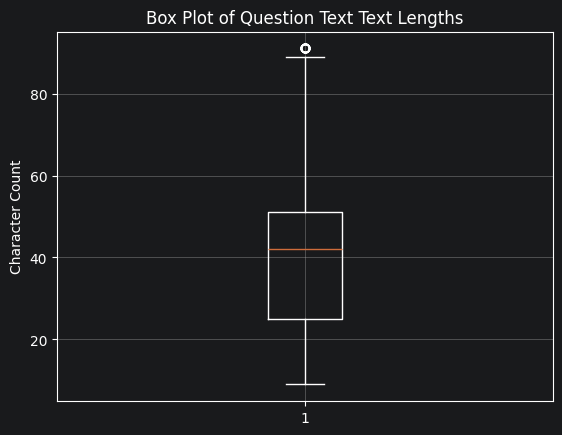

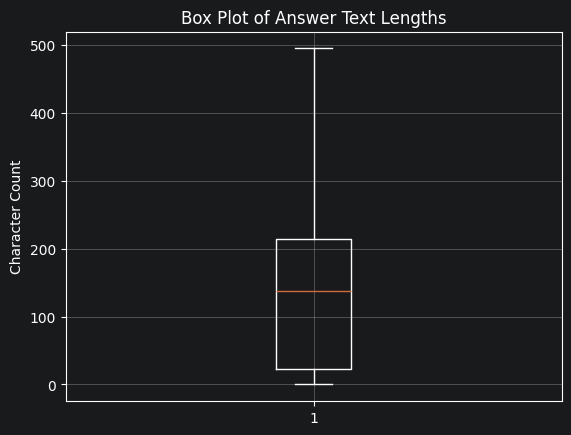







21:10:39 [INFO    ]: 

-------- Plant Expert VQA Training Dataset Class Frequency Distributions --------




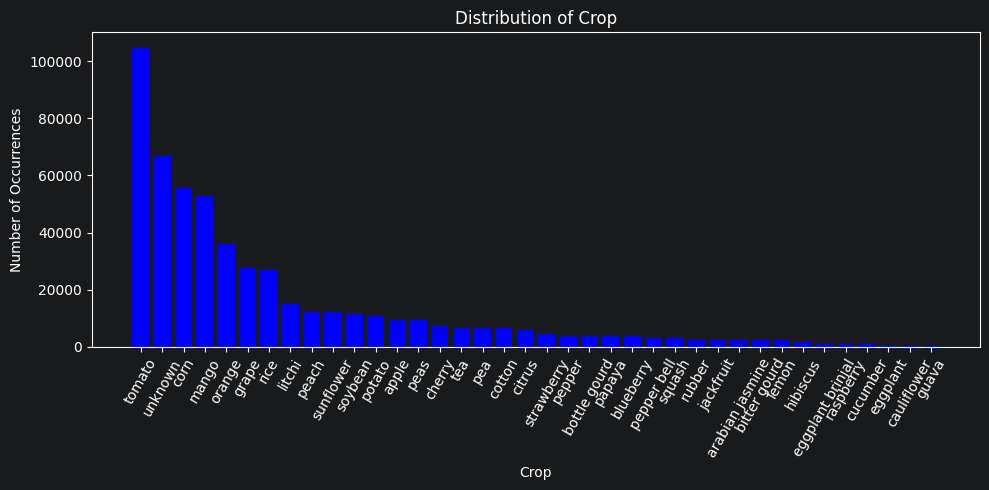

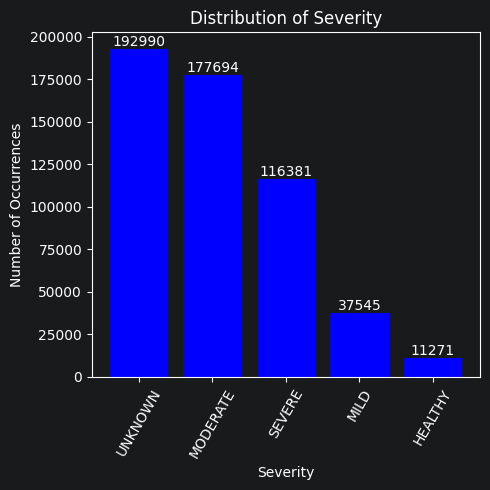

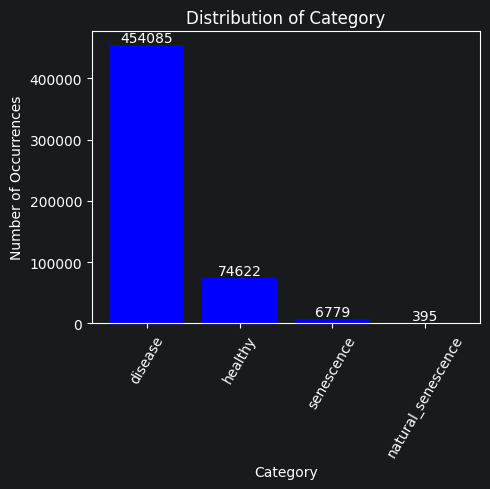

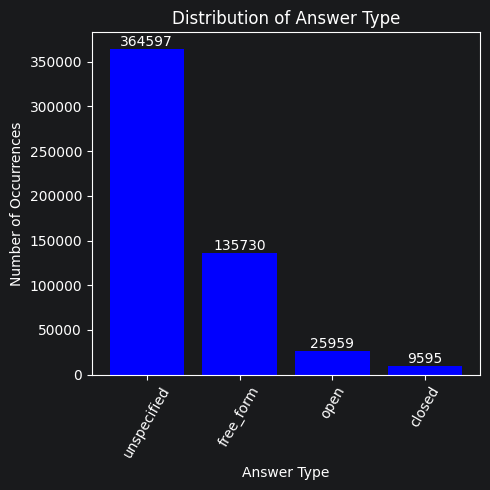

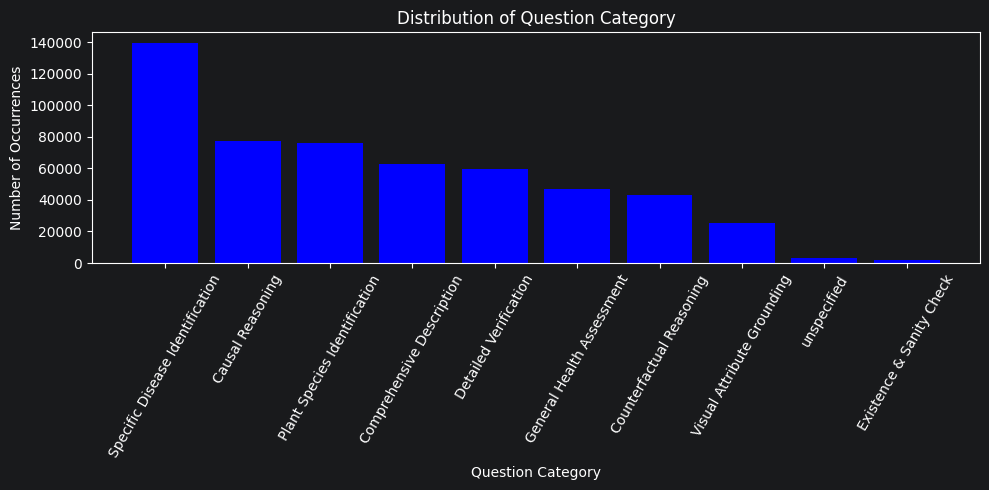







21:10:40 [INFO    ]: 

-------- Plant Expert VQA Training Dataset WordClouds --------




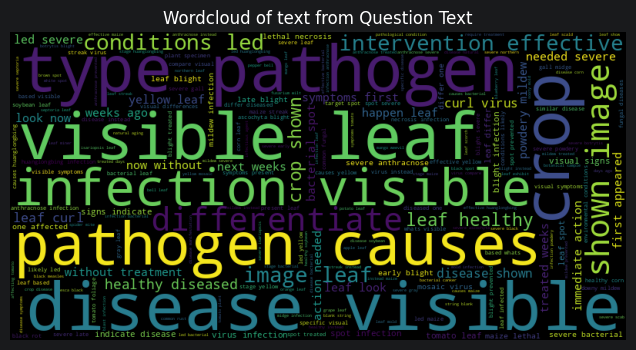

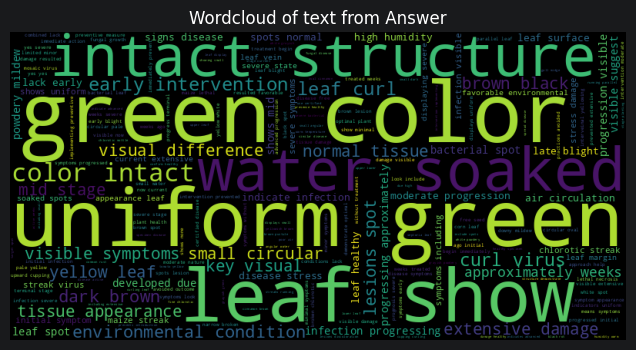







21:10:48 [INFO    ]: 

-------- Plant Expert VQA Training Dataset Word Frequency Distributions --------




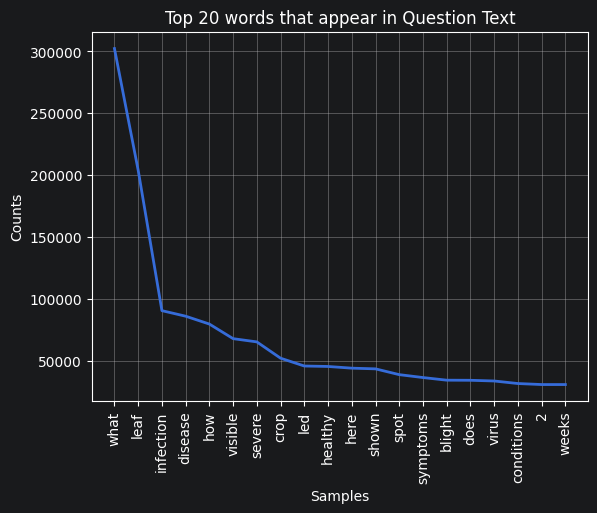

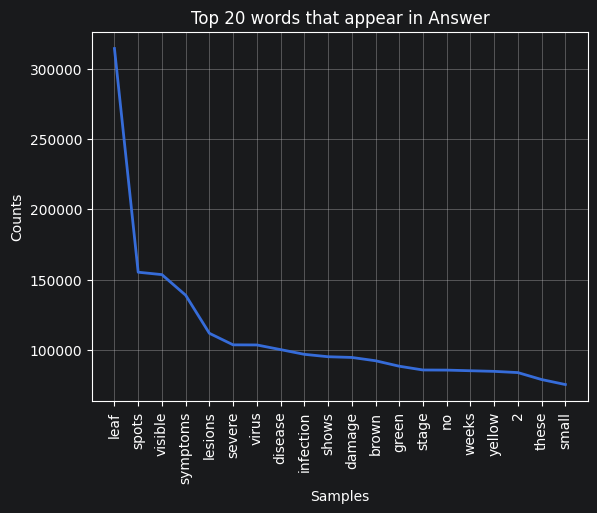

In [6]:

column_distribution_args= [
    {"column": "crop", "show_counts": False, "figure_size": (10, 5)},
    {"column": "severity", "show_counts": True, "figure_size": (5, 5)},
    {"column": "category", "show_counts": True, "figure_size": (5, 5)},
    {"column": "answer_type", "show_counts": True, "figure_size": (5, 5)},
    {"column": "question_category", "show_counts": False, "figure_size": (10, 5)},
]

# explore the cleaned training dataset
text_explore.explore_data(
    plant_expert_vqa_TRAIN, 
    column_distribution_args, 
    PEVQA_text_columns, 
    top_n_words=20, 
    name="Plant Expert VQA Training Dataset"
)

In [ ]:
# Testing the tokenizer and showing how to use it

# intialize the tokenizer
tokenizer= TextTokenizer("distilbert-base-uncased", 128)

# example of the passing in a single string to tokenize
inputs, attention_mask= tokenizer.encode_text("hello")
Logger.info(inputs)

# how to decode a single tensor output
output= tokenizer.decode(inputs)
Logger.info(output)

# encoding a list of strings
inputs, attention_mask= tokenizer.encode_text(["hello", "this is a test", "i am putting in multiple strings"])
Logger.info(inputs)

# decoding a list of tensors
output= tokenizer.batch_decode(inputs)
Logger.info(output)

# encoding a column of data
questions= plant_expert_vqa_TRAIN["question_text"]
inputs, attention_mask= tokenizer.encode_text(questions)

# decoding a all of those tensors
output= tokenizer.batch_decode(inputs)
Logger.info(f"first few decoded Tensors: \n\n{output[:10]}")


In [7]:
# Adding on macbook - will need to retest on workstation later tonight due to GPU acceleration
IMAGES_ROOT = DATA_DIR / "PlantExpertVQA"
traits = ["crop", "disease", "category", "severity"]

classes = {}
for t in traits:
    names = sorted(plant_expert_vqa_TRAIN[t].unique())  # adds names of plants
    classes[t] = names + ["unknown"]  # adds unknown species

train_ds = VisualModel.make_dataset(plant_expert_vqa_TRAIN, classes, IMAGES_ROOT, training=True)
val_ds = VisualModel.make_dataset(plant_expert_vqa_VAL, classes, IMAGES_ROOT)

#visual_model = VisualModel(classes=classes)
#visual_model.build()
#visual_model.compile()
#visual_model.fit(train_ds, val_ds, epochs=20)

I0000 00:00:1789607452.162010   36089 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13495 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4080 SUPER, pci bus id: 0000:01:00.0, compute capability: 8.9


In [ ]:
#import json
#Path("./models/visual_models/9_10_classes.json").write_text(json.dumps(classes))
#visual_model.save(path="./models/visual_models/9_10.keras")

In [8]:
MODEL_DIR = Path("./models/visual_models")
IMAGES_ROOT = DATA_DIR / "PlantExpertVQA"

vm = VisualModel.load(MODEL_DIR / "9_10.keras", MODEL_DIR/"9_10_classes.json")

21:10:54 [INFO    ]: 

-------- Test_VisualMoel: evaluating 152921 images --------




I0000 00:00:1789607455.465407   36280 service.cc:152] XLA service 0x7f224c003070 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1789607455.465432   36280 service.cc:160]   StreamExecutor device (0): NVIDIA GeForce RTX 4080 SUPER, Compute Capability 8.9
I0000 00:00:1789607455.854164   36280 cuda_dnn.cc:529] Loaded cuDNN version 92400
2026-09-16 21:11:02.686007: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-16 21:11:02.825164: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-16 21:11:03.419471: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-opti

21:14:49 [INFO    ]: 
               n  accuracy  top3_accuracy  macro_f1  majority_baseline
head                                                                  
crop      152921     0.637          0.871     0.633              0.194
disease   152921     0.400          0.663     0.427              0.148
category  152921     0.831          0.988     0.339              0.848
severity  152921     0.370          0.743     0.130              0.358
21:14:49 [INFO    ]: 
crop classification report:
                  precision    recall  f1-score   support

           apple       0.83      0.12      0.21      2841
 arabian jasmine       0.86      1.00      0.93       745
    bitter gourd       1.00      1.00      1.00       750
       blueberry       0.61      0.04      0.08      1080
    bottle gourd       0.96      1.00      0.98      1033
     cauliflower       0.67      0.94      0.78       148
          cherry       0.33      0.01      0.02      2257
          citrus       0.28      0.03

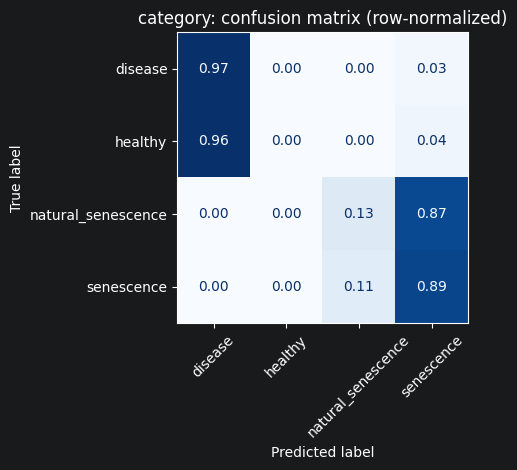

21:14:49 [INFO    ]: 
severity classification report:
              precision    recall  f1-score   support

     HEALTHY       0.00      0.00      0.00      3246
        MILD       0.55      0.02      0.04     10796
    MODERATE       0.60      0.02      0.04     51043
      SEVERE       0.72      0.01      0.03     33029
     UNKNOWN       0.37      1.00      0.53     54807
     unknown       0.00      0.00      0.00         0

    accuracy                           0.37    152921
   macro avg       0.37      0.18      0.11    152921
weighted avg       0.53      0.37      0.22    152921



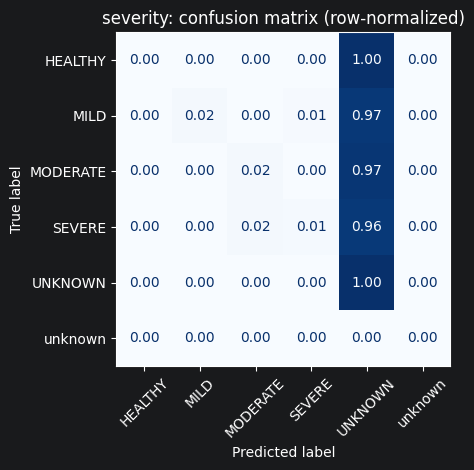

,n,accuracy,top3_accuracy,macro_f1,majority_baseline
head,,,,,
crop,152921,0.637,0.871,0.633,0.194
disease,152921,0.400,0.663,0.427,0.148
category,152921,0.831,0.988,0.339,0.848
severity,152921,0.370,0.743,0.130,0.358


In [9]:
test_table, test_predictions = visual_evaluator.evaluate(vm, plant_expert_vqa_TEST, IMAGES_ROOT, name="Test_VisualMoel")
test_table